# Part 1.

## (a)

In [39]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np

load_digits_dataset = load_digits()
print(load_digits_dataset)


{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)), 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)), 'frame': None, 'feature_names': ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_

## (b)

The "load_digits" dataset contains a collection of 8x8 drawn images of digits ranging from 0-10. The images are kept as matrix arrays, containing values ranging from 0.0-16.0. It has 1797 instances in total. For each drawn image(instance) there are 64 pixels (features).

In [40]:
print("No. of classes:", len(np.unique(load_digits_dataset.target)))
print("Classes:", np.unique(load_digits_dataset.target))
print("Pixel min value:", load_digits_dataset.data.min())
print("Pixel max value:", load_digits_dataset.data.max())
print("No. of pixels for each image (features):", load_digits_dataset.data.shape[1])

No. of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
Pixel min value: 0.0
Pixel max value: 16.0
No. of pixels for each image (features): 64


## (c)

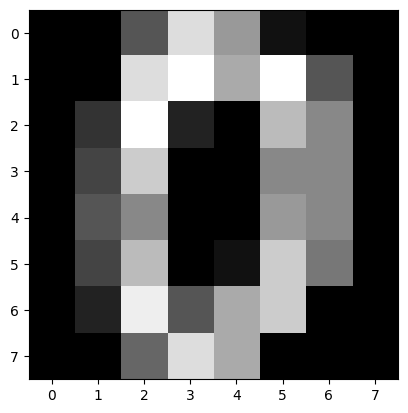

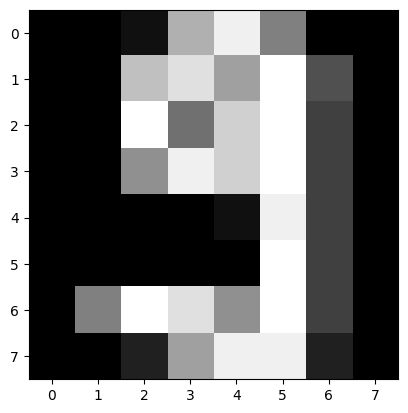

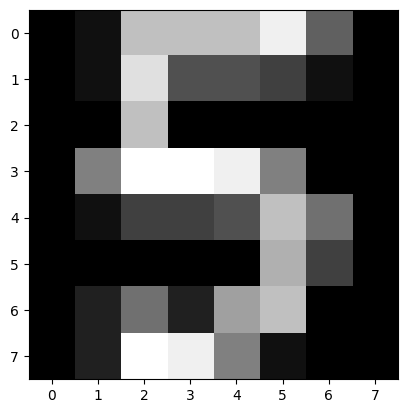

In [41]:
import matplotlib.pyplot as plt

plt.imshow(load_digits_dataset.images[0], cmap="grey")
plt.show()
plt.imshow(load_digits_dataset.images[128], cmap="grey")
plt.show()
plt.imshow(load_digits_dataset.images[1420], cmap="grey")
plt.show()

# there is no need to reshape, since it is already a matrix

## (d)

When it comes to K-means clustering, normalizing the data prevents high magnitude features from dominating other features in the distance calculations. For example, if we have a dataset where we're clustering based on income(1000) and age(21), income would be much higher than age and exaggerating the effect of income on the distance. Normalizing them makes them more easily comparable.

## (e)

We think the best approach would be use min-max scaling to normalize the pixel values. Because distance based algorithms like K-means work best with values that are in the range of 0.0-1.0.

# 2.

## (a)

In [42]:
from sklearn.cluster import KMeans

kmeans_cluster = KMeans(n_clusters=10,n_init="auto",random_state=0).fit(load_digits_dataset.data)
print(kmeans_cluster.inertia_)

1171289.220491156


He above is the within sum of squared distances we got.

## (b)

In [43]:
from sklearn.metrics import adjusted_rand_score

cluster_labels = kmeans_cluster.labels_
target_labels = load_digits_dataset.target
ars = adjusted_rand_score(target_labels,cluster_labels)

print(ars)

0.6153537727935613


As we can see here above, we got an Adjusted Random Score of 0.615. This indicates a good aggreement. It is significantly better than random chance, our clustering has discovered a real and meaningful structure in the data but not a perfect match.

## (c)

In [44]:
from sklearn.metrics import silhouette_score

labels = kmeans_cluster.fit_predict(load_digits_dataset.data)

sil_score = silhouette_score(load_digits_dataset.data, labels)

print(sil_score)

0.18555026309037873


As we can see here above, we got a silhouette score of 0.185. This indicates a weak structure but possibly some cluster pattern. We suspect that this might be because of similarities between some numbers, for example, 1 and 7 are look similar.

## (d)

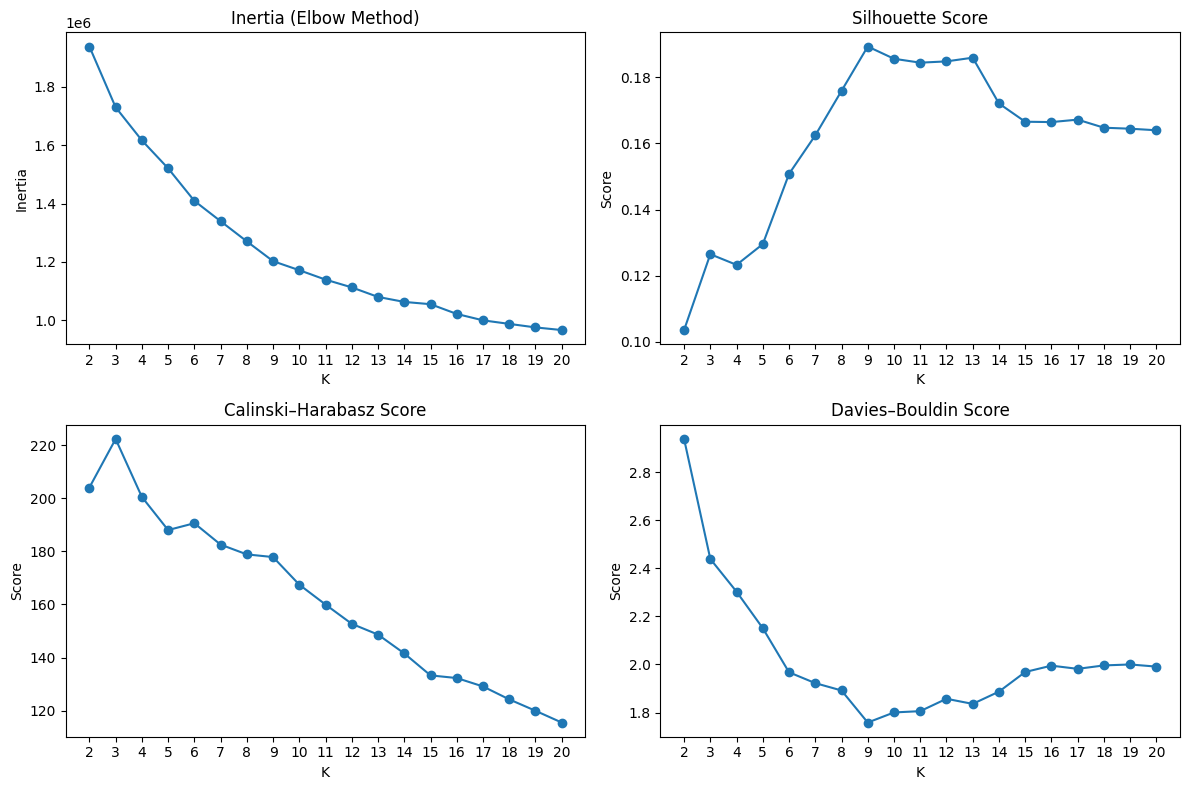

In [45]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

START_RANGE = 2
END_RANGE = 20
K_RANGE = range(START_RANGE,END_RANGE+1)

inertia_list = []
sil_list = []
ch_list = []
db_list = []

for k in K_RANGE:
    current_kmean = KMeans(n_clusters=k,random_state=0)
    current_labels = current_kmean.fit_predict(load_digits_dataset.data)

    inertia_list.append(current_kmean.inertia_)
    sil_list.append(silhouette_score(load_digits_dataset.data, current_labels))
    ch_list.append(calinski_harabasz_score(load_digits_dataset.data, current_labels))
    db_list.append(davies_bouldin_score(load_digits_dataset.data,current_labels))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

axes[0].set_xticks(list(K_RANGE))
axes[0].plot(K_RANGE, inertia_list, marker="o")
axes[0].set_title("Inertia (Elbow Method)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].set_xticks(list(K_RANGE))
axes[1].plot(K_RANGE, sil_list, marker="o")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")

axes[2].set_xticks(list(K_RANGE))
axes[2].plot(K_RANGE, ch_list, marker="o")
axes[2].set_title("Calinski–Harabasz Score")
axes[2].set_xlabel("K")
axes[2].set_ylabel("Score")

axes[3].set_xticks(list(K_RANGE))
axes[3].plot(K_RANGE, db_list, marker="o")
axes[3].set_title("Davies–Bouldin Score")
axes[3].set_xlabel("K")
axes[3].set_ylabel("Score")

plt.tight_layout()
plt.show()

He above are plots depicting the stats we got from clustering with differen K values, ranging from 2 to 20. 

The conclusions we can draw from the plots...
- Inertia
  - We can find the best cluster by locating the "elbow" of the plot. The elbow is very ambigious When we look at the plot we got, we cannot gleam any optimal specific optimal cluster from this plot.
- Silhouette Score
  - We can find the best cluster by locating the peak silhouette value, because a high silhouette score indicates the most compact and well seperated clusters. Having 9 clusters resulted in the highest silhouette score.
- Calinski-Harabasz Score
  - We can find the best cluster by finding the highest ch score or when the value plateaus. It seems that the ch score plateaus right after 9 clusters is tried. This might indicated that having 9 clusters gives the best cluster.
  - Calinski-harabasz score measures the ratio betweencluster dispersion within cluster dispersion. Having a higher ch score means the clusters are denser and well seperated.
- Davies-Bouldin Score
  - We can find the best cluster by finding the lowest Davies-Bouldin score.The lowest Davies-Bouldin Score that comes up is when we have 9 clusters.
  - Davies bouldin score represents the average similarity between clusters, so having a lower score means that there is less overlap and tighter clusters.

We conclude that the optimal number of clusters for this dataset appears to be 9. Due to the results we've gleamed from our plots.